In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [23]:
y_label = {0: "Politics", 1: "Sport", 2: "Technology", 3: "Entertainment", 4: "Business"}

In [24]:
df = pd.read_csv("df_file.csv")

In [25]:
df.head()

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


In [26]:
df.shape

(2225, 2)

In [27]:
X = df["Text"]
y = df["Label"]

# Train, Test Split dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

# Text Vectorization

In [10]:
vectorizer = CountVectorizer()

In [11]:
X_train_vectorized = vectorizer.fit_transform(X_train)

In [12]:
X_test_vectorized = vectorizer.transform(X_test)

In [13]:
features = vectorizer.get_feature_names_out()

In [14]:
X_test_vectorized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 107022 stored elements and shape (557, 26052)>

In [15]:
X_train_vectorized.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1668, 26052))

In [17]:
for feature in vectorizer.get_feature_names_out():
    print(feature)

00
000
0001
000m
000s
000th
001
001and
001st
004
007
01
0100
011
0130
02
0200
028
03
0300
037
03bn
04
0400
04bn
04m
05
050
050505
0530gmt
056
05bn
05m
06
060
069
06bn
07
070
0700
0710
0730
07bn
08
080
0800
081
0845
086
0870
088
08bn
09
0900
093
0950
09bn
09secs
10
100
1000
1000m
1000th
100bn
100m
100ml
100s
101
102
102m
103
1030
104
104m
105
105bn
105m
106
106cm
106m
107
108
1080
109
109m
10bn
10cm
10ft
10k
10m
10s
10secs
10th
10x7in
11
110
1100
110m
110th
111
1115
111m
112
113
1130
1130p
113bn
113th
114
115
116
117m
117th
118
119bn
119m
11b
11bn
11m
11pm
11th
12
120
1200
1200m
120bn
120gb
120m
121
1218
1230
124bn
125
125m
127
127th
128
129
12a
12bn
12cm
12km
12m
12th
13
130
1300
130cm
130m
131
132
133
1330
1337
133m
134
134m
135
135m
136
136m
137
137m
138m
138p
139
13bn
13m
13s
13th
14
140
1400
140bn
140m
141
142
142bn
142m
143
1430
143m
144
1441
145
145m
146
147
148
149
149bn
14bn
14m
14th
15
150
1500
1500m
150bn
150m
150th
151
152
152m
153
153m
154m
155
155bn
155m
156
156m
157
157m


# Naive Bayes (Multinomial)

In [19]:
class NaiveBayes:

    def __init__(self):

        self.classes = list() #list for unique classes
        self.n_items = 0 # number of items
        self.n_features = 0 # number of features
        self.class_priors = dict() #class prior probability
        self.class_occurence_indexes = dict() 
        self.total_class_count = dict()
        self.total_word_count_in_class = dict()
        self.word_likelihoods = dict() # word likelihood probability
        

    def fit(self, X, y):

        self.X_train = X
        self.y_train = y.reset_index(drop=True)
        self.n_items, self.n_features = self.X_train.shape
        self.classes = np.unique(self.y_train)

        #class count
        for c in self.classes:
            self.class_occurence_indexes[c] = list(self.y_train[self.y_train == c].index)
            self.total_class_count[c] = len(self.y_train[self.y_train == c])

        # total words count in each class
        for c, indexes in self.class_occurence_indexes.items():
            self.total_word_count_in_class[c] = int(self.X_train.toarray()[indexes].sum())

        # print(self.total_word_count_in_class)

        self._calculate_prior()
        self._calculate_likelihood()

        

    def _calculate_prior(self):

        for c in self.classes:
            
            self.class_priors[c] = self.total_class_count[c] / self.y_train.shape[0]


    def _calculate_likelihood(self):

        # total_class_count = dict()
        # print(self.total_class_count)
        # print(self.X_train.toarray())

        for c in self.classes:

            # self.word_likelihoods[c] = list()

            # class_mask = self.y_train == c
            x = self.X_train.toarray()[self.class_occurence_indexes[c]].sum(axis=0)

            # print(sum(x))

            # for count, feature in zip(x, features):
            matrix = [0 for _ in range(self.n_features)]
            for i, count in enumerate(x):

                # if count > 0:
                # matrix[i] = count / self.total_word_count_in_class[c]
                matrix[i] = (count + 1) / (
                        self.total_word_count_in_class[c] + self.n_features
                    )
                # print(i)

            self.word_likelihoods[c] = matrix
            # print(matrix)

        # print(self.word_likelihoods)

    def predict(self, X):

        x_matrix = X.toarray()
        # print(x_matrix)

        results = list()

        for row in x_matrix:

            # print(row)
            indices = np.where(row > 0)
            # print(indices)

            result = dict()

            for c, l in self.word_likelihoods.items():
                l = np.array(l)
                # likelihood = 1
                # print(len(l))

                log_posterior = np.log(self.class_priors[c])

                for i in indices[0]:
                    log_posterior += row[i] * np.log(l[i])
                
                result[c] = log_posterior

            results.append(max(result, key=lambda x: result[x]))

                
        return results

        

        

# Main

In [20]:
naive = NaiveBayes()

In [21]:
naive.fit(X_train_vectorized, y_train)

In [33]:
naive.classes

array([0, 1, 2, 3, 4])

In [34]:
naive.class_priors

{np.int64(0): 0.1828537170263789,
 np.int64(1): 0.22961630695443644,
 np.int64(2): 0.18345323741007194,
 np.int64(3): 0.1750599520383693,
 np.int64(4): 0.2290167865707434}

In [35]:
y_predictions = naive.predict(X_test_vectorized)

In [36]:
for i in y_predictions:
    print(i)

0
1
3
0
2
3
4
2
1
2
0
1
3
0
1
1
4
1
0
1
0
2
0
1
0
2
1
4
1
3
3
2
4
1
0
1
4
4
4
3
4
2
0
3
4
4
4
1
0
4
1
1
2
0
1
2
2
2
0
2
0
1
1
0
3
1
0
0
2
3
2
2
4
3
0
4
3
1
0
0
4
4
0
1
1
0
4
2
1
3
3
0
2
0
3
0
1
1
0
2
0
2
4
0
3
2
3
4
1
2
1
4
1
0
2
3
1
1
1
3
1
2
0
2
4
4
4
1
0
1
3
1
1
3
3
2
0
0
1
4
4
0
2
0
4
1
4
1
0
2
4
1
0
4
4
3
3
1
0
1
4
1
1
2
4
1
0
4
4
1
2
4
4
1
3
4
2
2
0
3
2
3
0
2
4
3
1
3
4
0
0
3
1
4
4
1
2
2
3
4
3
1
0
4
0
2
3
2
3
4
3
2
4
1
3
2
4
4
0
4
0
0
0
1
2
2
2
2
0
1
3
3
1
2
4
0
1
0
4
0
4
1
2
3
0
0
0
0
4
0
2
3
4
0
1
4
1
3
3
4
2
4
0
1
3
1
2
3
1
1
0
0
0
1
0
3
1
2
4
0
0
4
0
0
1
4
2
3
1
4
4
4
0
1
2
0
0
4
1
4
3
2
4
2
4
1
0
1
4
1
3
0
3
4
4
4
3
0
0
3
2
4
3
0
1
0
0
4
3
2
2
0
3
0
1
3
2
3
3
2
0
4
4
0
1
0
2
1
3
4
4
4
1
1
2
3
1
3
4
4
1
4
0
4
3
4
2
2
1
4
0
4
4
0
4
0
2
2
3
4
2
3
1
0
0
3
0
4
4
1
2
4
3
3
3
1
3
3
2
1
4
3
1
1
2
0
1
1
2
4
4
1
4
3
4
3
3
2
4
2
1
2
1
2
3
0
1
2
3
2
3
2
1
4
2
4
4
4
3
2
1
0
2
1
1
3
4
3
4
1
0
4
1
1
2
2
0
0
0
4
1
2
0
3
3
4
0
0
3
4
3
2
1
2
2
3
0
2
3
4
1
3
0
0
4
4
1
2
1
2
1
1
1
2
0
3
4
4
4
0


In [37]:
y_test.tolist()

[0,
 1,
 3,
 0,
 2,
 3,
 4,
 2,
 1,
 2,
 0,
 1,
 3,
 0,
 1,
 1,
 4,
 1,
 0,
 1,
 0,
 4,
 0,
 1,
 0,
 2,
 1,
 4,
 1,
 3,
 3,
 2,
 4,
 1,
 0,
 1,
 0,
 4,
 4,
 3,
 4,
 2,
 0,
 3,
 4,
 4,
 4,
 1,
 0,
 4,
 1,
 1,
 2,
 0,
 1,
 2,
 2,
 2,
 0,
 0,
 0,
 1,
 1,
 0,
 3,
 1,
 0,
 0,
 2,
 3,
 2,
 2,
 4,
 3,
 0,
 4,
 3,
 1,
 0,
 0,
 4,
 4,
 0,
 1,
 1,
 4,
 4,
 2,
 1,
 3,
 3,
 0,
 2,
 0,
 3,
 0,
 1,
 1,
 0,
 2,
 0,
 2,
 4,
 0,
 3,
 2,
 3,
 4,
 1,
 2,
 1,
 4,
 1,
 0,
 2,
 3,
 1,
 1,
 1,
 3,
 1,
 2,
 0,
 2,
 4,
 4,
 4,
 1,
 0,
 1,
 3,
 1,
 1,
 3,
 3,
 2,
 0,
 0,
 1,
 4,
 4,
 0,
 2,
 0,
 4,
 1,
 4,
 1,
 0,
 2,
 3,
 1,
 0,
 4,
 4,
 3,
 3,
 1,
 0,
 1,
 4,
 1,
 1,
 2,
 4,
 1,
 0,
 4,
 4,
 1,
 2,
 4,
 4,
 1,
 3,
 4,
 2,
 2,
 0,
 3,
 2,
 3,
 0,
 2,
 4,
 3,
 1,
 3,
 4,
 0,
 0,
 3,
 1,
 4,
 4,
 1,
 2,
 2,
 3,
 4,
 3,
 1,
 0,
 4,
 0,
 2,
 3,
 2,
 3,
 4,
 3,
 2,
 4,
 1,
 3,
 2,
 4,
 4,
 0,
 4,
 0,
 0,
 0,
 1,
 2,
 2,
 2,
 2,
 0,
 1,
 3,
 3,
 1,
 2,
 4,
 4,
 1,
 0,
 4,
 0,
 4,
 1,
 2,
 3,
 0,
 0,
 0,
 0,
 4,
 0,


In [38]:
# accuracy_score(y_predictions,y_test)

In [39]:
print(accuracy_score(y_test.tolist(), y_predictions))

0.9676840215439856


In [49]:
conf_matrix = confusion_matrix(y_test, y_predictions)

In [50]:
conf_matrix

array([[109,   0,   1,   0,   2],
       [  1, 127,   0,   0,   0],
       [  0,   0,  93,   2,   0],
       [  3,   0,   2,  88,   1],
       [  2,   0,   3,   1, 122]])

<Axes: >

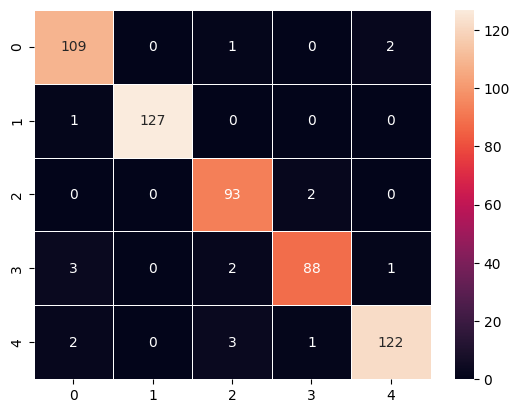

In [56]:
sns.heatmap(conf_matrix, annot=True,linewidths=.5,fmt=".0f")

In [64]:
a = vectorizer.transform(["Picture this as a classification problem where we want to sort reviews of customers using a bag-of-words approach for predefined 10 words: this means that a review corresponds to a row sample, and features represent the number of times each word appears in the review. In the real world, this dataset would be the output of your data extraction and preprocessing."])

In [65]:
pred = naive.predict(a)

In [66]:
for p in pred:
    print(y_label[p])

Technology
